# Experiment 1.3.8 — SNN Local Feature Preservation

## Scientific question

Experiment 1.3.7 showed that the current SNN representation contains **complementary information beyond coarse Raw250 counts**, but SNN-only performance is less stable and does not reliably preserve all of the robust count-based information.

The goal here is **not** to keep a Raw+SNN fusion branch at inference. The final target remains an SNN-only local feature extractor:

\[
X_{\mathrm{spike}} \rightarrow \mathrm{continuous\ SNN} \rightarrow z_1,z_2,\ldots,z_B,
\qquad z_b\in\mathbb{R}^{64}.
\]

For every 250 ms window, the L3 local feature is

\[
z_b=\sum_{t\in W_b}S_t^{L3}.
\]

The SNN state remains continuous across the full gesture and is **not reset at 250 ms boundaries**. The bins are readout windows only.

### Hypothesis

The current SNN can learn useful temporal information, but it may discard part of the robust local channel-semantic structure present in Raw250 counts. Explicit auxiliary objectives should make that information easily decodable from the 64-D latent feature without forcing individual SNN neurons to correspond to individual raw channels.

## Representation-shaping objectives

### 1. Whole-gesture classification

As in Experiment 1.3.5, all 250 ms local features are concatenated and a whole-gesture classifier supplies

\[
L_{\mathrm{cls}}=CE(\hat y,y).
\]

### 2. Semantic count preservation

For each 250 ms input window:

\[
c_b[c]=\sum_{t\in W_b}X_{t,c}\in\mathbb{R}^{30}.
\]

Raw channels have fixed semantics, whereas the 64 SNN neurons form a distributed latent representation. Therefore we **do not** impose `z[:30] ≈ c`. Instead a training-only linear decoder learns

\[
\hat c_b=W_cz_b+b_c,
\]

which requires the robust 30-channel information to remain **linearly decodable** from the 64-D SNN feature. Counts are transformed with `log1p`, standardized per channel using train users only, and trained with masked SmoothL1 loss. Partial valid bins are weighted by their valid fraction and padded bins are ignored.

### 3. Within-window temporal preservation

Each 250 ms window is divided into early and late 125 ms halves. Let their channel counts be `q_E` and `q_L`. For an active channel:

\[
r_b[c]=\frac{q_b^E[c]-q_b^L[c]}{q_b^E[c]+q_b^L[c]+\epsilon}\in[-1,1].
\]

A second training-only linear decoder predicts this normalized temporal contrast. Temporal loss is computed only for fully valid 250 ms bins and channels with non-zero activity.

### Full objective

\[
\boxed{L=L_{\mathrm{cls}}+\lambda_cL_{\mathrm{count}}+\lambda_tL_{\mathrm{temp}}}
\]

The semantic decoder, temporal decoder, and global classifier are training/evaluation tools. The final deployed output is only `z_b`.

In [1]:
from pathlib import Path

def find_repo_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
SCRIPT_DIR = REPO_ROOT / 'scripts/experiment_1_3_8_local_feature_preservation'
print('Repository root:', REPO_ROOT)
print('Implementation:', SCRIPT_DIR)


Repository root: /home/ted/project/writingring-viz
Implementation: /home/ted/project/writingring-viz/scripts/experiment_1_3_8_local_feature_preservation


## 1. Data, split, and auxiliary targets

This cell loads the same 64 Hz / 30-channel unsigned event dataset and fixed `SPLIT_SEED=12345` user-disjoint split used by Experiments 1.3.5–1.3.7. It also constructs the semantic-count and early/late temporal targets using train-only normalization statistics.

In [2]:
path = SCRIPT_DIR / '01_setup.py'
exec(compile(path.read_text(), str(path), 'exec'), globals())


Repository root: /home/ted/project/writingring-viz
Device: cuda
Experiment: experiment_1_3_8_snn_local_feature_preservation
samples=853, users=20, classes=12
labels: ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
train/val/test: (632, 256, 30) (126, 256, 30) (95, 256, 30)
readout: 16 samples = 250.0 ms
{'train_users': ('user_0', 'user_1', 'user_11', 'user_12', 'user_14', 'user_19', 'user_2', 'user_3', 'user_4', 'user_5', 'user_6', 'user_7', 'user_8', 'user_9'), 'val_users': ('user_15', 'user_16', 'user_20'), 'test_users': ('user_10', 'user_13', 'user_18')}
semantic target mean range: 0.0356464609503746 0.24721388518810272
semantic target std range: 0.07761354744434357 0.2478490024805069
train temporal active elements: 50332


## 2. Model, masked objectives, training, and fresh SNN-only probe

The backbone is intentionally unchanged from Experiment 1.3.5:

\[30\rightarrow128\rightarrow128\rightarrow64\]

with shifts `((2,3), (2,3), (2,))`, `tau_mem=22.54 ms`, threshold `0.5`, and continuous state. The two auxiliary decoders are both `Linear(64, 30)` and exist only to shape the latent representation during training.

In [3]:
path = SCRIPT_DIR / '02_model_training.py'
exec(compile(path.read_text(), str(path), 'exec'), globals())


Raw250 validation-selected C: 0.1
Raw250 val BA: 0.713260582010582
Test remains untouched during development.


## 3. Development sweep and final runs

### Conditions

- **A — `cls_only`**: `L_cls`
- **B — `cls_count`**: `L_cls + lambda_c L_count`
- **C — `cls_count_temp`**: `L_cls + lambda_c L_count + lambda_t L_temp`

### Hyperparameter protocol

Development uses seed 11 only. First sweep `lambda_c ∈ {0.05, 0.10, 0.30}`, select by **validation SNN-only Logistic Regression BA**; then lock it and sweep `lambda_t ∈ {0.05, 0.10, 0.30}` using the same criterion. Auxiliary reconstruction loss is not the selection metric.

The test set is not evaluated during development. After both lambdas are locked, final training runs A/B/C for seeds `(11, 23, 101)`.

### Primary metric

After training, freeze the SNN and ignore all training heads. Flatten the `16 × 64` SNN local-feature map and train a fresh `StandardScaler + LogisticRegression`; choose `C ∈ {1e-3,1e-2,1e-1,1,10}` on validation only, then report test balanced accuracy. This SNN-only probe is the primary measure of local-feature quality.

In [4]:
path = SCRIPT_DIR / '03_run_primary.py'
exec(compile(path.read_text(), str(path), 'exec'), globals())


Loaded completed checkpoint: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_1_3_8_snn_local_feature_preservation/development/dev_cls_count_lc_0.05_seed_11.pt
Loaded completed checkpoint: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_1_3_8_snn_local_feature_preservation/development/dev_cls_count_lc_0.1_seed_11.pt
Loaded completed checkpoint: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_1_3_8_snn_local_feature_preservation/development/dev_cls_count_lc_0.3_seed_11.pt
Selected lambda_count = 0.1


,stage,lambda_count,lambda_temp,best_epoch,global_val_BA,probe_selected_C,probe_val_BA
0,count,0.05,0.0,84,0.614881,0.10,0.600992
1,count,0.10,0.0,93,0.650860,0.01,0.638161
2,count,0.30,0.0,79,0.633036,0.01,0.625860


/home/ted/project/writingring-viz/scripts/experiment_1_3_8_local_feature_preservation/02_model_training.py:120: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensors = [torch.from_numpy(a) for a in SPLIT_ARRAYS[split]]


cls_count_temp   seed= 11 epoch=  1 | train BA=0.0748 val BA=0.0833 | L=2.5483 (cls=2.4857, count=0.3882, temp=0.4757) | L3 FR=0.0001
cls_count_temp   seed= 11 epoch= 10 | train BA=0.3316 val BA=0.2013 | L=1.9538 (cls=1.8900, count=0.3896, temp=0.4958) | L3 FR=0.0097
cls_count_temp   seed= 11 epoch= 20 | train BA=0.7061 val BA=0.4203 | L=0.9023 (cls=0.8397, count=0.3793, temp=0.4920) | L3 FR=0.0339
cls_count_temp   seed= 11 epoch= 30 | train BA=0.8468 val BA=0.4375 | L=0.5452 (cls=0.4865, count=0.3531, temp=0.4676) | L3 FR=0.0498
cls_count_temp   seed= 11 epoch= 40 | train BA=0.8910 val BA=0.4841 | L=0.3606 (cls=0.3048, count=0.3349, temp=0.4464) | L3 FR=0.0633
cls_count_temp   seed= 11 epoch= 50 | train BA=0.9353 val BA=0.4883 | L=0.2526 (cls=0.1980, count=0.3282, temp=0.4363) | L3 FR=0.0614
cls_count_temp   seed= 11 epoch= 60 | train BA=0.9623 val BA=0.5393 | L=0.1909 (cls=0.1372, count=0.3230, temp=0.4268) | L3 FR=0.0742
cls_count_temp   seed= 11 epoch= 70 | train BA=0.9764 val BA=0

,stage,lambda_count,lambda_temp,best_epoch,global_val_BA,probe_selected_C,probe_val_BA
0,count,0.05,0.00,84,0.614881,0.10,0.600992
1,count,0.10,0.00,93,0.650860,0.01,0.638161
2,count,0.30,0.00,79,0.633036,0.01,0.625860
3,temp,0.10,0.05,92,0.580853,0.01,0.589517
4,temp,0.10,0.10,100,0.662202,10.00,0.652943
5,temp,0.10,0.30,97,0.600959,0.01,0.611739


Locked Raw250 selected C: 0.1
Locked Raw250 test BA: 0.546957671957672
FINAL: cls_only seed= 11 lambda_count= 0.0 lambda_temp= 0.0
cls_only         seed= 11 epoch=  1 | train BA=0.0748 val BA=0.0833 | L=2.4861 (cls=2.4861, count=0.3890, temp=0.4762) | L3 FR=0.0001
cls_only         seed= 11 epoch= 10 | train BA=0.3168 val BA=0.1815 | L=1.9063 (cls=1.9063, count=0.5727, temp=0.6576) | L3 FR=0.0096
cls_only         seed= 11 epoch= 20 | train BA=0.7003 val BA=0.3467 | L=0.8643 (cls=0.8643, count=1.2026, temp=1.2866) | L3 FR=0.0380
cls_only         seed= 11 epoch= 30 | train BA=0.8254 val BA=0.4993 | L=0.5304 (cls=0.5304, count=1.4711, temp=1.5775) | L3 FR=0.0540
cls_only         seed= 11 epoch= 40 | train BA=0.8853 val BA=0.5062 | L=0.3543 (cls=0.3543, count=1.6901, temp=1.7671) | L3 FR=0.0637
cls_only         seed= 11 epoch= 50 | train BA=0.9223 val BA=0.5461 | L=0.2504 (cls=0.2504, count=1.7529, temp=1.7962) | L3 FR=0.0654
cls_only         seed= 11 epoch= 60 | train BA=0.9567 val BA=0.60

,condition,seed,lambda_count,lambda_temp,best_epoch,train_global_BA,val_global_BA,test_global_accuracy,test_global_BA,test_global_macro_f1,test_loss_count,test_loss_temp,test_l1_fr,test_l2_fr,test_l3_fr,test_l1_dead_fraction,test_l2_dead_fraction,test_l3_dead_fraction
0,cls_only,11,0.0,0.0,91,0.987625,0.652480,0.484211,0.496197,0.466706,2.719052,2.609040,0.008398,0.051858,0.108788,0.156250,0.015625,0.0
1,cls_only,23,0.0,0.0,90,0.975549,0.633598,0.515789,0.539683,0.516093,2.463710,2.185061,0.007458,0.046220,0.102112,0.132812,0.007812,0.0
2,cls_only,101,0.0,0.0,64,0.970945,0.648578,0.484211,0.504464,0.479749,2.247206,2.537660,0.007902,0.040730,0.088344,0.156250,0.031250,0.0
3,cls_count,11,0.1,0.0,80,0.978715,0.646131,0.494737,0.500165,0.485692,0.367577,2.541858,0.008407,0.049985,0.103751,0.109375,0.039062,0.0
4,cls_count,23,0.1,0.0,96,0.987715,0.627017,0.431579,0.445271,0.436649,0.369511,2.221451,0.007556,0.040488,0.095187,0.156250,0.015625,0.0
5,cls_count,101,0.1,0.0,82,0.973225,0.634888,0.505263,0.511243,0.508134,0.369756,2.230226,0.007421,0.039866,0.079391,0.132812,0.023438,0.0
6,cls_count_temp,11,0.1,0.1,100,0.989231,0.662202,0.473684,0.483135,0.463506,0.365860,0.445326,0.008797,0.052580,0.104944,0.140625,0.015625,0.0
7,cls_count_temp,23,0.1,0.1,100,0.986028,0.643320,0.515789,0.543155,0.504947,0.368279,0.453817,0.008050,0.044985,0.086529,0.164062,0.007812,0.0
8,cls_count_temp,101,0.1,0.1,98,0.978761,0.659888,0.484211,0.494874,0.478348,0.368135,0.449444,0.008456,0.043868,0.096661,0.148438,0.031250,0.0


,representation,condition,seed,feature_dim,selected_C,val_BA,test_accuracy,test_BA,test_macro_f1,delta_test_BA_vs_Raw250
0,SNN250,cls_only,11,1024,0.01,0.664517,0.505263,0.510913,0.495902,-0.036045
1,SNN250,cls_only,23,1024,0.01,0.632705,0.568421,0.592593,0.569395,0.045635
2,SNN250,cls_only,101,1024,0.01,0.620800,0.515789,0.530423,0.509955,-0.016534
3,SNN250,cls_count,11,1024,0.10,0.604233,0.452632,0.446429,0.419665,-0.100529
4,SNN250,cls_count,23,1024,0.01,0.659425,0.505263,0.531250,0.511292,-0.015708
5,SNN250,cls_count,101,1024,0.01,0.641634,0.547368,0.549769,0.539918,0.002811
6,SNN250,cls_count_temp,11,1024,10.00,0.652943,0.410526,0.422950,0.392327,-0.124008
7,SNN250,cls_count_temp,23,1024,0.01,0.664054,0.515789,0.540179,0.501329,-0.006779
8,SNN250,cls_count_temp,101,1024,0.01,0.673776,0.536842,0.562004,0.535963,0.015046


,condition,n_runs,mean_test_BA,sd_test_BA,mean_test_accuracy,mean_test_macro_f1,mean_delta_test_BA_vs_Raw250,sd_delta_test_BA_vs_Raw250
0,Raw250 baseline,1,0.546958,NaN,0.536842,0.541218,0.000000,NaN
1,cls_count,3,0.509149,0.055101,0.501754,0.490292,-0.037809,0.055101
2,cls_count_temp,3,0.508377,0.074783,0.487719,0.476540,-0.038580,0.074783
3,cls_only,3,0.544643,0.042656,0.529825,0.525084,-0.002315,0.042656


## 4. Secondary diagnostics

Three diagnostics help interpret the primary SNN-only result:

1. **Fresh semantic linear probe:** after training, a new linear regressor measures how well 30-channel semantic counts can be decoded from `z_b`; it does not reuse the training decoder.
2. **Fresh temporal linear probe:** measures how well early-vs-late temporal contrast remains linearly decodable.
3. **Raw250 + SNN diagnostic fusion:** retained only to test whether temporal complementarity survives. It is **not** the intended inference architecture.

Firing rates and dead-neuron fractions are also saved so any accuracy gain can be checked against changes in the firing regime.

,condition,seed,semantic_val_MAE,semantic_val_R2,semantic_test_MAE,semantic_test_R2,temporal_channels_fit,temporal_val_MAE,temporal_test_MAE,temporal_val_mean_channel_R2,temporal_test_mean_channel_R2
0,cls_only,11,0.668912,0.156504,0.727919,0.177998,30,0.885020,0.896345,0.005448,-0.038633
1,cls_only,23,0.679336,0.133059,0.730228,0.166616,30,0.891251,0.884270,0.015499,0.013725
2,cls_only,101,0.674989,0.132871,0.730900,0.159951,30,0.894080,0.899233,0.016187,-0.025956
3,cls_count,11,0.673594,0.150128,0.731242,0.166705,30,0.890922,0.898575,0.003579,-0.028464
4,cls_count,23,0.673701,0.138637,0.731130,0.169347,30,0.891134,0.887469,0.011503,0.012995
5,cls_count,101,0.674644,0.137277,0.737614,0.151701,30,0.893309,0.899111,0.008421,-0.026041
6,cls_count_temp,11,0.670740,0.151509,0.728490,0.170854,30,0.886366,0.881993,0.007835,0.002217
7,cls_count_temp,23,0.676585,0.131463,0.730115,0.168345,30,0.891021,0.896041,-0.000270,-0.021607
8,cls_count_temp,101,0.671766,0.142936,0.730785,0.168374,30,0.883601,0.882396,0.015211,-0.005972


,condition,semantic_test_MAE_mean,semantic_test_R2_mean,temporal_test_MAE_mean,temporal_test_R2_mean
0,cls_count,0.733329,0.162585,0.895051,-0.013837
1,cls_count_temp,0.729797,0.169191,0.886810,-0.008454
2,cls_only,0.729682,0.168188,0.893282,-0.016955


,condition,seed,snn_only_test_BA,raw250_test_BA,raw_plus_snn_test_BA,fusion_delta_vs_raw,fusion_delta_vs_snn,selected_C
0,cls_only,11,0.510913,0.546958,0.597884,0.050926,0.086971,0.10
1,cls_only,23,0.592593,0.546958,0.593254,0.046296,0.000661,0.10
2,cls_only,101,0.530423,0.546958,0.585483,0.038525,0.055060,0.01
3,cls_count,11,0.446429,0.546958,0.582507,0.035549,0.136078,0.01
4,cls_count,23,0.531250,0.546958,0.595899,0.048942,0.064649,0.10
5,cls_count,101,0.549769,0.546958,0.573578,0.026620,0.023810,1.00
6,cls_count_temp,11,0.422950,0.546958,0.561673,0.014716,0.138724,0.01
7,cls_count_temp,23,0.540179,0.546958,0.583995,0.037037,0.043816,0.10
8,cls_count_temp,101,0.562004,0.546958,0.580522,0.033565,0.018519,0.10


,condition,mean_snn_only_test_BA,mean_raw_plus_snn_test_BA,mean_fusion_delta_vs_raw,sd_fusion_delta_vs_raw
0,cls_count,0.509149,0.583995,0.037037,0.011235
1,cls_count_temp,0.508377,0.575397,0.028439,0.012011
2,cls_only,0.544643,0.592207,0.045249,0.006266


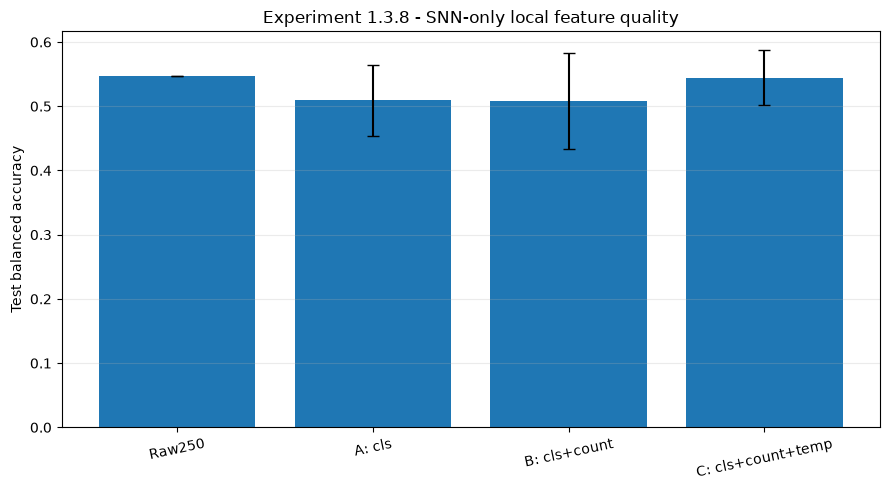

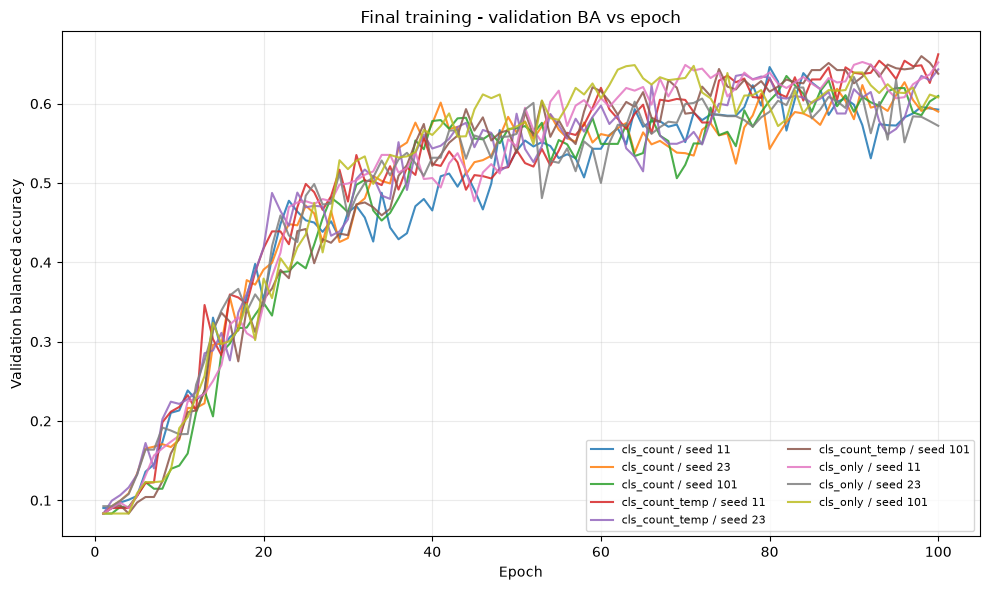

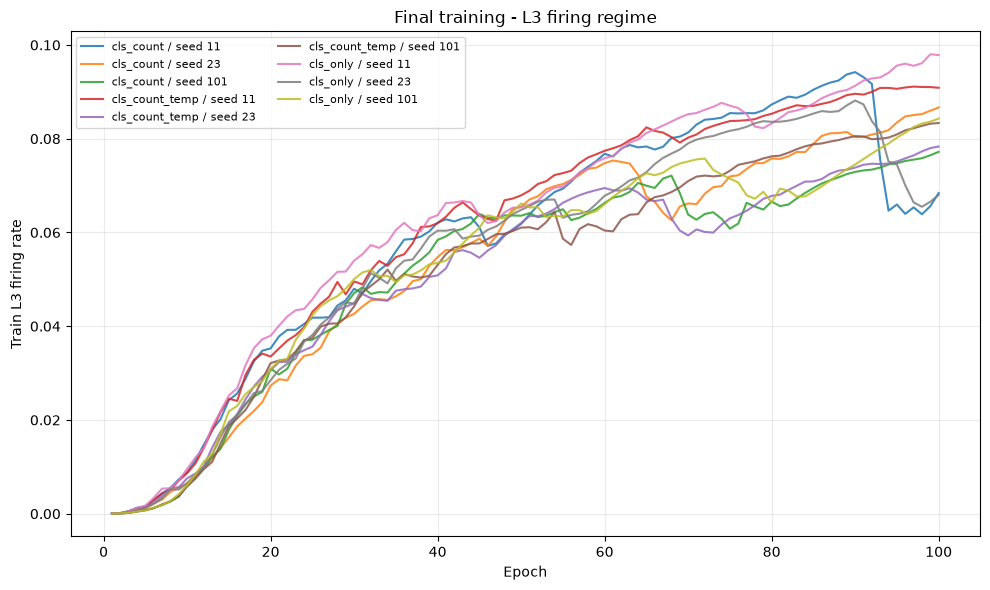

Selected lambda_count: 0.1
Selected lambda_temp: 0.1
Raw250 test BA: 0.546957671957672
Saved outputs to: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_1_3_8_snn_local_feature_preservation


,condition,n_runs,mean_test_BA,sd_test_BA,mean_test_accuracy,mean_test_macro_f1,mean_delta_test_BA_vs_Raw250,sd_delta_test_BA_vs_Raw250
0,Raw250 baseline,1,0.546958,NaN,0.536842,0.541218,0.000000,NaN
1,cls_count,3,0.509149,0.055101,0.501754,0.490292,-0.037809,0.055101
2,cls_count_temp,3,0.508377,0.074783,0.487719,0.476540,-0.038580,0.074783
3,cls_only,3,0.544643,0.042656,0.529825,0.525084,-0.002315,0.042656


,condition,semantic_test_MAE_mean,semantic_test_R2_mean,temporal_test_MAE_mean,temporal_test_R2_mean
0,cls_count,0.733329,0.162585,0.895051,-0.013837
1,cls_count_temp,0.729797,0.169191,0.886810,-0.008454
2,cls_only,0.729682,0.168188,0.893282,-0.016955


,condition,mean_snn_only_test_BA,mean_raw_plus_snn_test_BA,mean_fusion_delta_vs_raw,sd_fusion_delta_vs_raw
0,cls_count,0.509149,0.583995,0.037037,0.011235
1,cls_count_temp,0.508377,0.575397,0.028439,0.012011
2,cls_only,0.544643,0.592207,0.045249,0.006266


In [5]:
path = SCRIPT_DIR / '04_diagnostics.py'
exec(compile(path.read_text(), str(path), 'exec'), globals())


## 5. Interpretation rules

### Strong success
`cls_count_temp` gives a stable SNN-only BA above Raw250 across seeds. This supports the claim that the SNN can preserve robust channel-semantic information while adding useful temporal structure.

### Partial success
SNN-only mean BA approaches Raw250 and seed-to-seed variance decreases substantially relative to `cls_only`. The preservation objectives improve representation robustness even if they do not yet beat Raw250.

### Count-copy failure mode
Semantic decodability becomes very strong, SNN-only performance approaches Raw250, but Raw+SNN no longer improves over Raw. The SNN may have collapsed toward a count-like representation; reduce `lambda_c` or redesign/strengthen temporal preservation.

### Temporal-objective failure mode
If `cls_count_temp` is worse than `cls_count`, inspect temporal-mask coverage, the fresh temporal probe, and whether the 125 ms early/late target is too restrictive.

### Firing-regime failure mode
If gains require a large increase in L3 firing rate or a large loss of sparsity, quantify that trade-off before adopting the objective.

The final intended representation always remains:

\[
\boxed{X_{\mathrm{spike}}\rightarrow SNN\rightarrow z_1,z_2,\ldots,z_B}
\]
